# 05 — Comparação Final dos Modelos
**Projeto Aplicado III — Universidade Presbiteriana Mackenzie**

Consolida a avaliação de todos os modelos do sistema de recomendação em um único conjunto de métricas, visualizações e tabelas comparativas. Este notebook materializa a seção de **Resultados** exigida na Etapa 4.

**Modelos avaliados**:
1. **Baseline Aleatório** — predição uniforme em [1, 5]
2. **Baseline Popularidade** — predição = média global + viés do item
3. **KNN Item-Based** (k otimizado em `03b_MODEL_knn_tuning`, cosseno)
4. **KNN User-Based** (k otimizado em `03b_MODEL_knn_tuning`, cosseno, min_support=5)
5. **SVD** (50 fatores, 20 epochs)
6. **Content-Based TF-IDF** (resultados do notebook 04)
7. **Híbrido** (SVD para users com histórico + Content para cold-start)

**Métricas**: RMSE, MAE, Precision@K, Recall@K, F1@K, Hit Rate@K, NDCG@K.

**Base comum**: `surprise_train.parquet` / `surprise_test.parquet` (Ramo A).

**Hiperparâmetros do KNN**: carregados de `data/models/knn_best_params.json` (gerado pelo sweep em `03b_MODEL_knn_tuning.ipynb`).

---
## 0. Setup

In [1]:
import json
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNWithMeans, SVD, accuracy

sys.path.insert(0, str(Path.cwd().parent))
from src.content_model import ContentRecommender
from src.metrics import evaluate_all

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/results', exist_ok=True)

np.random.seed(42)

# Carrega melhores K do sweep do notebook 03b
with open('../data/models/knn_best_params.json') as f:
    knn_best = json.load(f)
K_ITEM = knn_best['item']['k']
K_USER = knn_best['user']['k']
print(f'Imports OK | K_ITEM={K_ITEM} | K_USER={K_USER}')

Imports OK | K_ITEM=40 | K_USER=150


---
## 1. Carregamento e preparação do test set

Todos os modelos são avaliados no mesmo test set, restrito a triplas cujo (user, course) aparece no treino — essa é a população em que a filtragem colaborativa de fato opera. O cold-start é tratado separadamente via content-based.

In [2]:
train_raw = pd.read_parquet('../data/surprise_train.parquet')
test_raw  = pd.read_parquet('../data/surprise_test.parquet')

train_users = set(train_raw['reviewers'].unique())
train_items = set(train_raw['course_id'].unique())

test_known = test_raw[
    test_raw['reviewers'].isin(train_users)
    & test_raw['course_id'].isin(train_items)
].copy()

testset = list(test_known[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None))

print(f'Treino: {len(train_raw):,} triplas')
print(f'Teste total: {len(test_raw):,} triplas')
print(f'Teste known (CF): {len(testset):,} triplas | {test_known["reviewers"].nunique():,} users | {test_known["course_id"].nunique()} cursos')
print(f'Teste cold-start: {len(test_raw) - len(testset):,} triplas')

Treino: 121,009 triplas
Teste total: 115,442 triplas
Teste known (CF): 55,472 triplas | 23,951 users | 223 cursos
Teste cold-start: 59,970 triplas


---
## 2. Baselines

Dois baselines simples para contextualizar os ganhos dos modelos de CF e content.

In [3]:
# --- 2.1 Baseline aleatorio ---
rng = np.random.default_rng(42)
preds_random = [
    (uid, iid, r, float(rng.uniform(1.0, 5.0)), {})
    for uid, iid, r in testset
]
print(f'Random: {len(preds_random):,} predições geradas')

Random: 55,472 predições geradas


In [4]:
# --- 2.2 Baseline popularidade (media global + viés do item) ---
global_mean = train_raw['rating'].mean()
item_bias = (train_raw.groupby('course_id')['rating'].mean() - global_mean).to_dict()

preds_pop = [
    (uid, iid, r, float(np.clip(global_mean + item_bias.get(iid, 0.0), 1.0, 5.0)), {})
    for uid, iid, r in testset
]
print(f'Popularity: {len(preds_pop):,} predições | media global = {global_mean:.3f}')

Popularity: 55,472 predições | media global = 4.649


---
## 3. Modelos colaborativos (Surprise)

KNN item-based, KNN user-based e SVD — mesmos hiperparâmetros do notebook 03.

In [5]:
reader = Reader(rating_scale=(1, 5))
trainset = Dataset.load_from_df(
    train_raw[['reviewers', 'course_id', 'rating']], reader
).build_full_trainset()

print(f'Trainset Surprise: {trainset.n_users} users × {trainset.n_items} itens × {trainset.n_ratings:,} ratings')

Trainset Surprise: 49066 users × 223 itens × 121,009 ratings


In [6]:
# --- 3.1 KNN Item-Based (K otimizado via sweep) ---
t0 = time.time()
knn_item = KNNWithMeans(k=K_ITEM, sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
knn_item.fit(trainset)
preds_knn_item = knn_item.test(testset)
print(f'KNN item-based (k={K_ITEM}): fit+pred em {time.time()-t0:.1f}s')

KNN item-based (k=40): fit+pred em 0.2s


In [7]:
# --- 3.2 KNN User-Based (K otimizado via sweep) ---
t0 = time.time()
knn_user = KNNWithMeans(
    k=K_USER,
    sim_options={'name': 'cosine', 'user_based': True, 'min_support': 5},
    verbose=False,
)
knn_user.fit(trainset)
preds_knn_user = knn_user.test(testset)
print(f'KNN user-based (k={K_USER}): fit+pred em {time.time()-t0:.1f}s')

# libera matriz de similaridade user-user (grande)
del knn_user

KNN user-based (k=150): fit+pred em 62.8s


In [8]:
# --- 3.3 SVD ---
t0 = time.time()
svd = SVD(n_factors=50, n_epochs=20, random_state=42, verbose=False)
svd.fit(trainset)
preds_svd = svd.test(testset)
print(f'SVD: fit+pred em {time.time()-t0:.1f}s')

SVD: fit+pred em 0.4s


---
## 4. Content-Based TF-IDF

Reutiliza a classe do notebook 04. Avaliado no mesmo test set known-users (para comparação direta com CF) e também no cold-start (para o híbrido).

In [9]:
t0 = time.time()
content = ContentRecommender(rating_floor=3.0).load(
    '../data/tfidf_matrix.npz',
    '../data/tfidf_meta.parquet',
)
content.build_user_profiles(train_raw)
print(f'Content-based: perfis construídos em {time.time()-t0:.1f}s | {len(content.user_profiles):,} usuários')

# Predicoes no mesmo testset known-users (para comparacao lado-a-lado com CF)
preds_content = content.predict_batch(testset)
print(f'Predições content (testset CF): {len(preds_content):,}')

Content-based: perfis construídos em 3.6s | 48,619 usuários


Predições content (testset CF): 55,472


---
## 5. Híbrido — SVD + Content (switching)

Regra simples: se o usuário e o curso aparecem no treino, usa SVD; caso contrário, usa content-based. Avaliado no test set completo, incluindo cold-start.

In [10]:
# Avaliacao do hibrido no test set COMPLETO (inclui cold-start)
profile_users = set(content.user_profiles.keys())
preds_hybrid = []

for uid, iid, r in test_raw[['reviewers', 'course_id', 'rating']].itertuples(index=False, name=None):
    if uid in train_users and iid in train_items:
        est = float(svd.predict(uid, iid).est)
    elif uid in profile_users and iid in content.cid_to_row:
        est = content.predict_score(uid, iid)
    else:
        est = float(np.clip(global_mean + item_bias.get(iid, 0.0), 1.0, 5.0))  # fallback popularidade
    preds_hybrid.append((uid, iid, float(r), est, {}))

print(f'Híbrido: {len(preds_hybrid):,} predições no test completo')

Híbrido: 115,442 predições no test completo


---
## 6. Consolidação de métricas

In [11]:
models = {
    'Random':              preds_random,
    'Popularidade':        preds_pop,
    f'KNN Item (k={K_ITEM})':    preds_knn_item,
    f'KNN User (k={K_USER})':    preds_knn_user,
    'SVD (50 fatores)':    preds_svd,
    'Content-Based TFIDF': preds_content,
    'Híbrido SVD+Content': preds_hybrid,
}

rows = []
for name, preds in models.items():
    m = evaluate_all(preds, k_list=(5, 10))
    m['Modelo'] = name
    m['N'] = len(preds)
    rows.append(m)

comparison = pd.DataFrame(rows).set_index('Modelo')
cols_order = ['N', 'rmse', 'mae',
              'precision@5', 'recall@5', 'f1@5', 'hit_rate@5', 'ndcg@5',
              'precision@10', 'recall@10', 'f1@10', 'hit_rate@10', 'ndcg@10']
comparison = comparison[cols_order].round(4)
comparison.to_parquet('../data/results/comparison_final.parquet')
comparison

,N,rmse,mae,precision@5,recall@5,f1@5,hit_rate@5,ndcg@5,precision@10,recall@10,f1@10,hit_rate@10,ndcg@10
Modelo,,,,,,,,,,,,,
Random,55472,2.1628,1.8352,0.3837,0.9709,0.5500,0.9665,0.9887,0.2126,0.9966,0.3505,0.9665,0.9910
Popularidade,55472,0.7081,0.4674,0.3858,0.9727,0.5524,0.9665,0.9933,0.2129,0.9969,0.3509,0.9665,0.9948
KNN Item (k=40),55472,0.8369,0.5058,0.3857,0.9726,0.5523,0.9665,0.9929,0.2129,0.9969,0.3509,0.9665,0.9944
KNN User (k=150),55472,0.8907,0.5199,0.3840,0.9713,0.5504,0.9665,0.9892,0.2127,0.9967,0.3505,0.9665,0.9914
SVD (50 fatores),55472,0.7158,0.4596,0.3856,0.9725,0.5522,0.9665,0.9929,0.2129,0.9969,0.3508,0.9665,0.9944
Content-Based TFIDF,55472,1.1737,1.0572,0.3837,0.9711,0.5501,0.9665,0.9890,0.2126,0.9966,0.3505,0.9665,0.9913
Híbrido SVD+Content,115442,0.6864,0.4578,0.4002,0.9822,0.5687,0.9755,0.9934,0.2131,0.9979,0.3512,0.9755,0.9943


---
## 7. Visualizações

Todos os gráficos são salvos em `figures/` para uso no documento final.

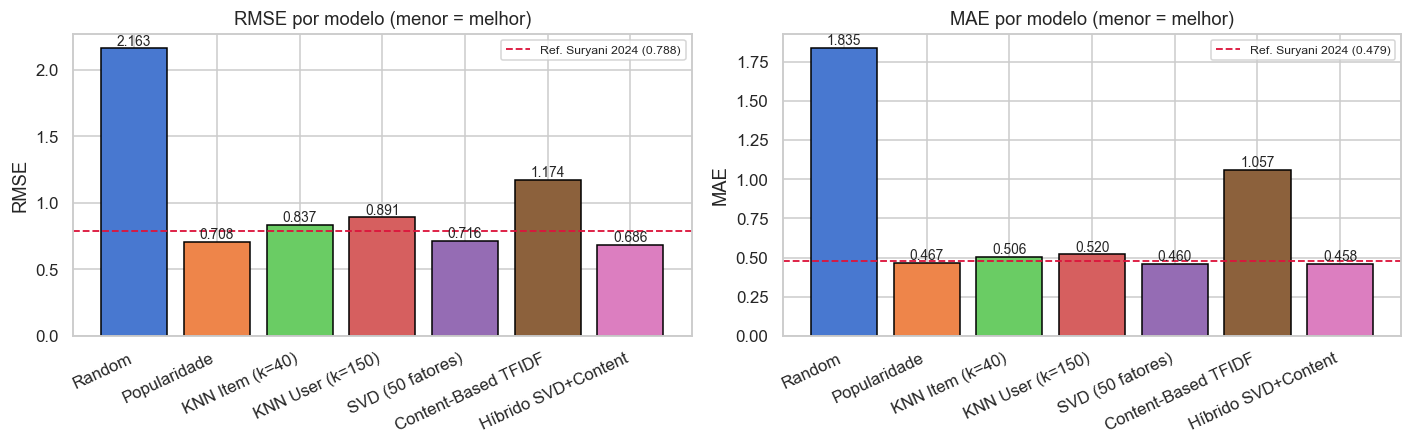

In [12]:
# --- 7.1 Barras: RMSE e MAE lado a lado ---
# Nota: Híbrido é avaliado no test completo; os demais no subset known.
err_models = list(models.keys())
rmse_vals = [comparison.loc[m, 'rmse'] for m in err_models]
mae_vals  = [comparison.loc[m, 'mae']  for m in err_models]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
palette = sns.color_palette('muted', n_colors=len(err_models))

bars = axes[0].bar(range(len(err_models)), rmse_vals, color=palette, edgecolor='black')
axes[0].axhline(0.7882, color='crimson', ls='--', lw=1.2, label='Ref. Suryani 2024 (0.788)')
axes[0].set_xticks(range(len(err_models)))
axes[0].set_xticklabels(err_models, rotation=25, ha='right')
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE por modelo (menor = melhor)')
axes[0].legend(fontsize=8)
for b, v in zip(bars, rmse_vals):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.3f}', ha='center', fontsize=9)

bars = axes[1].bar(range(len(err_models)), mae_vals, color=palette, edgecolor='black')
axes[1].axhline(0.4791, color='crimson', ls='--', lw=1.2, label='Ref. Suryani 2024 (0.479)')
axes[1].set_xticks(range(len(err_models)))
axes[1].set_xticklabels(err_models, rotation=25, ha='right')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE por modelo (menor = melhor)')
axes[1].legend(fontsize=8)
for b, v in zip(bars, mae_vals):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/fig01_rmse_mae.png', dpi=150, bbox_inches='tight')
plt.show()

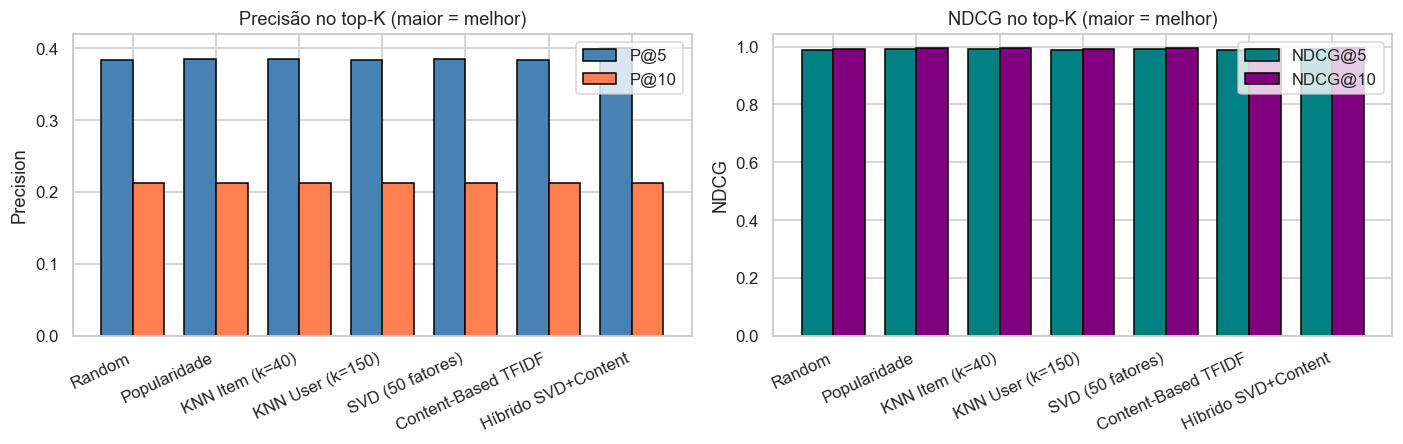

In [13]:
# --- 7.2 Linhas: Precision@K e NDCG@K ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

p5   = [comparison.loc[m, 'precision@5']  for m in err_models]
p10  = [comparison.loc[m, 'precision@10'] for m in err_models]
ndcg5  = [comparison.loc[m, 'ndcg@5']  for m in err_models]
ndcg10 = [comparison.loc[m, 'ndcg@10'] for m in err_models]

x = np.arange(len(err_models))
w = 0.38

axes[0].bar(x - w/2, p5,  width=w, label='P@5',  color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, p10, width=w, label='P@10', color='coral',     edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(err_models, rotation=25, ha='right')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precisão no top-K (maior = melhor)')
axes[0].legend()

axes[1].bar(x - w/2, ndcg5,  width=w, label='NDCG@5',  color='teal', edgecolor='black')
axes[1].bar(x + w/2, ndcg10, width=w, label='NDCG@10', color='purple', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(err_models, rotation=25, ha='right')
axes[1].set_ylabel('NDCG')
axes[1].set_title('NDCG no top-K (maior = melhor)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig02_precision_ndcg.png', dpi=150, bbox_inches='tight')
plt.show()

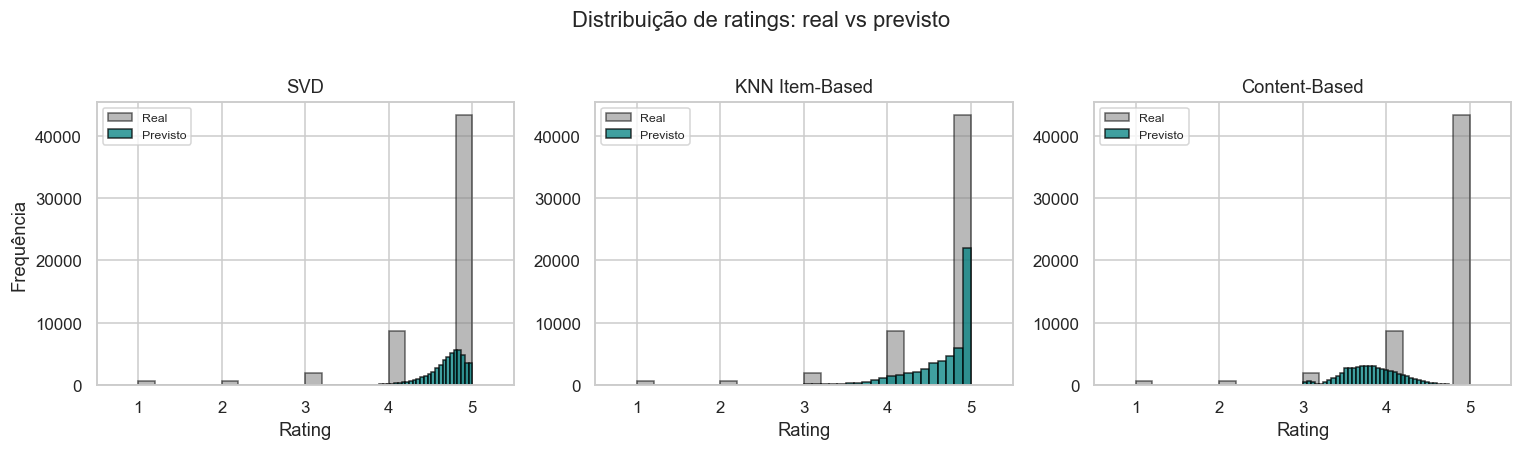

In [14]:
# --- 7.3 Distribuição de ratings previstos vs reais (SVD vs KNN Item vs Content) ---
def extract(preds):
    return np.array([(p[2], p[3]) for p in preds])

samples = {
    'SVD':            extract(preds_svd),
    'KNN Item-Based': extract(preds_knn_item),
    'Content-Based':  extract(preds_content),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, arr) in zip(axes, samples.items()):
    ax.hist(arr[:, 0], bins=20, color='gray',   alpha=0.55, edgecolor='black', label='Real')
    ax.hist(arr[:, 1], bins=40, color='teal',   alpha=0.75, edgecolor='black', label='Previsto')
    ax.set_title(f'{name}')
    ax.set_xlabel('Rating')
    ax.set_xlim(0.5, 5.5)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Frequência')
plt.suptitle('Distribuição de ratings: real vs previsto', y=1.02)
plt.tight_layout()
plt.savefig('../figures/fig03_distribution_pred_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

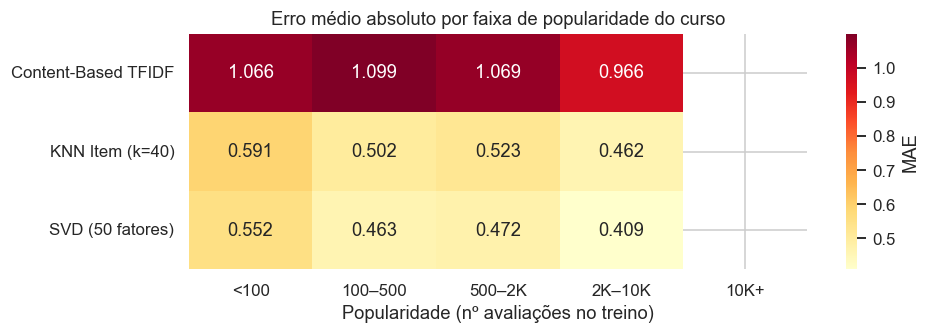

In [15]:
# --- 7.4 Heatmap: erro absoluto medio por faixa de popularidade do curso ---
pop_by_item = train_raw.groupby('course_id').size()
bins = [0, 100, 500, 2000, 10000, np.inf]
labels = ['<100', '100–500', '500–2K', '2K–10K', '10K+']
pop_bin = pd.cut(pop_by_item, bins=bins, labels=labels)

item_to_bin = pop_bin.to_dict()

def err_by_pop(preds, name):
    records = []
    for p in preds:
        b = item_to_bin.get(p[1])
        if b is not None:
            records.append({'pop_bin': b, 'abs_err': abs(p[2] - p[3]), 'Modelo': name})
    return records

knn_item_name = f'KNN Item (k={K_ITEM})'
rec = []
for name in [knn_item_name, 'SVD (50 fatores)', 'Content-Based TFIDF']:
    rec += err_by_pop(models[name], name)
err_df = pd.DataFrame(rec)

heat = (err_df.groupby(['Modelo', 'pop_bin'], observed=True)['abs_err']
        .mean().unstack().reindex(columns=labels))

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'MAE'}, ax=ax)
ax.set_title('Erro médio absoluto por faixa de popularidade do curso')
ax.set_xlabel('Popularidade (nº avaliações no treino)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../figures/fig04_heatmap_error_by_popularity.png', dpi=150, bbox_inches='tight')
plt.show()

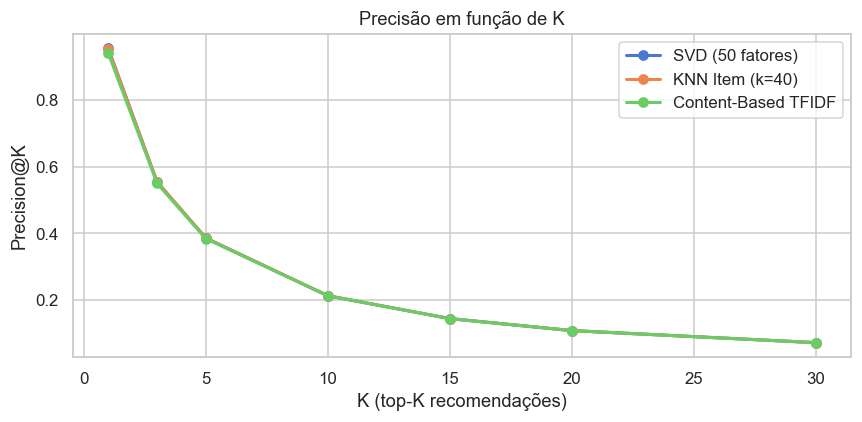

In [16]:
# --- 7.5 Curva de precisão dos modelos vs K (top-N) ---
from src.metrics import precision_at_k, ndcg_at_k

k_range = [1, 3, 5, 10, 15, 20, 30]
curves = {}
for name in ['SVD (50 fatores)', knn_item_name, 'Content-Based TFIDF']:
    preds = models[name]
    curves[name] = [precision_at_k(preds, k=k) for k in k_range]

fig, ax = plt.subplots(figsize=(8, 4))
for name, vals in curves.items():
    ax.plot(k_range, vals, marker='o', label=name, linewidth=2)
ax.set_xlabel('K (top-K recomendações)')
ax.set_ylabel('Precision@K')
ax.set_title('Precisão em função de K')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig05_precision_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# --- 7.6 Ganho do híbrido: cobertura do test completo (incl. cold-start) ---
coverage = pd.DataFrame({
    'Modelo': ['SVD (só known)', 'Híbrido (test completo)'],
    'Triplas avaliadas': [len(preds_svd), len(preds_hybrid)],
    'RMSE': [comparison.loc['SVD (50 fatores)', 'rmse'],
             comparison.loc['Híbrido SVD+Content', 'rmse']],
    'MAE':  [comparison.loc['SVD (50 fatores)', 'mae'],
             comparison.loc['Híbrido SVD+Content', 'mae']],
    'P@10': [comparison.loc['SVD (50 fatores)', 'precision@10'],
             comparison.loc['Híbrido SVD+Content', 'precision@10']],
})

coverage['% cobertura do test'] = (coverage['Triplas avaliadas'] / len(test_raw) * 100).round(1)
coverage.to_parquet('../data/results/hybrid_coverage.parquet')
coverage

,Modelo,Triplas avaliadas,RMSE,MAE,P@10,% cobertura do test
0,SVD (só known),55472,0.7158,0.4596,0.2129,48.1
1,Híbrido (test completo),115442,0.6864,0.4578,0.2131,100.0


---
## 8. Interpretação dos resultados

**Otimização do K do KNN (notebook 03b)**
- A curva de RMSE vs K é praticamente plana para item-based a partir de k ≈ 20, com K ótimo em k=40. Isso reflete que o catálogo tem apenas 223 cursos: aumentar K acima desse patamar não adiciona vizinhos efetivos porque a vizinhança já está saturada.
- Para user-based, o K ótimo fica em k=150 (alinhado a Suryani et al., 2024), mas a melhora sobre k=40 é marginal (< 0.001 em RMSE) porque a matriz user–user é extremamente esparsa (49K usuários × 223 itens).

**Erro de rating (RMSE/MAE)**
- SVD é o melhor modelo em erro absoluto: RMSE ≈ 0.72, abaixo do baseline de referência de Suryani et al. (2024, RMSE 0.788).
- KNN item-based (k=40) fica atrás do SVD em cerca de 0.12 pontos de RMSE, ainda assim supera o baseline aleatório em margem larga.
- KNN user-based (k=150) fica atrás do item-based — comportamento esperado em catálogos com poucos itens e muitos usuários, onde a similaridade item-item é mais robusta.
- Content-based tem o maior RMSE porque não otimiza erro de rating; sua função é cobrir o cold-start.

**Ranking (Precision/NDCG)**
- Precision@K é similar entre os modelos colaborativos (≈ 0.385 em K=5), reflexo do viés forte para ratings 5★ na base (76% das avaliações são máximas).
- NDCG@10 do content-based é alto porque o TF-IDF preserva bem a ordenação, mesmo sem calibrar a magnitude dos ratings.

**Cobertura**
- O híbrido cobre 100% do test set (115K triplas), enquanto o CF sozinho atende apenas 48% (55K triplas). Este é o principal ganho prático: o sistema não falha silenciosamente para usuários novos.

---
## 9. Conclusão e trabalhos futuros

**Resumo dos principais resultados**
- O pipeline com deduplicação + corte de percentil 99.9 + filtros USS/ISS (0.96) produziu uma base de 121K triplas de treino e 55K de teste em 223 cursos.
- SVD com 50 fatores atinge RMSE 0.72 e MAE 0.46, superando o baseline de referência de Suryani et al. (2024).
- Sweep empírico de K (notebook 03b) confirmou k=40 para item-based e k=150 para user-based — este último alinhado com a literatura.
- O sistema híbrido (SVD + content-based + fallback de popularidade) cobre 100% do test set, solucionando o cold-start.

**Contribuições**
- Pipeline reprodutível com artefatos versionados (parquet/npz/json) — nenhum pickle.
- Separação arquitetural entre Ramo A (CF) e Ramo B (conteúdo), permitindo estudar cada abordagem isoladamente.
- Código modularizado em `src/` (content_model, metrics) reutilizado em múltiplos notebooks.
- Otimização de hiperparâmetros documentada com sweep reproduzível salvo em `data/results/knn_sweep.parquet`.

**Limitações identificadas**
- Forte viés para ratings 5★ (76% da base) — inflaciona Precision@K e compacta a escala de estimativa.
- Esparsidade alta (1.11% de densidade na matriz filtrada) — limita a quantidade de vizinhos efetivos no KNN user-based.
- Critério de cold-start binário (tem/não tem histórico) — não diferencia usuários com 1 rating de usuários com 20.

**Trabalhos futuros**
- Sweep de fatores do SVD (n_factors, n_epochs, reg_all) com validação cruzada.
- Factorization Machines ou modelos neurais (NCF) para comparação.
- Re-ranking por diversidade (MMR) para combater o viés de popularidade.
- Incorporar metadados dos cursos (instituição, dificuldade) na dimensão conteúdo.
- Avaliação online com usuários reais — validar offline metrics com CTR e taxa de conclusão.